# Merge all method

Helper method 

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def normalize_and_enhance(image):
    # 1. Chuyển sang không gian màu LAB để xử lý độ sáng mà không làm biến đổi màu sắc gốc
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # 2. Áp dụng CLAHE để làm nổi bật các chi tiết mờ (như các phần đè lên nhau)
    # clipLimit cao (3.0-5.0) sẽ đẩy độ tương phản rất mạnh
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    # 3. Kéo giãn lược đồ (Min-Max Stretching) để chuẩn hóa độ đậm nhạt
    # Giúp ảnh nhạt trở nên đậm đà hơn
    l = cv2.normalize(l, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

    # Gộp lại
    enhanced_lab = cv2.merge((l, a, b))
    enhanced_bgr = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

    # 4. Tăng độ bão hòa màu (Saturation) để các tế bào có màu đặc trưng hơn (tím/đỏ)
    hsv = cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2HSV).astype("float32")
    (h, s, v) = cv2.split(hsv)
    
    # Nhân hệ số s (Saturation) để màu đậm lên, ví dụ 1.2 hoặc 1.5
    s = s * 1.3
    s = np.clip(s, 0, 255)
    
    hsv = cv2.merge([h, s, v])
    final_img = cv2.cvtColor(hsv.astype("uint8"), cv2.COLOR_HSV2BGR)

    return final_img

def median_filter(image, kernel_size=3):
    return cv2.medianBlur(image, kernel_size)

#Make process frequen
def median_dilation(img, iters = 1):
    #Median first
    img_median = cv2.medianBlur(img, 5)
    kernel = np.ones((3, 3), np.uint8)
    while iters > 0:
        #Dilation
        img_median = cv2.dilate(img_median, kernel, iterations=1)
        #Median again
        img_median = cv2.medianBlur(img_median, 5)
        iters -= 1
    return img_median

def get_neighbors(graph, vertex):
    neighbors = []
    x, y = vertex
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue
            nx, ny = x + dx, y + dy
            if 0 <= nx < graph.shape[0] and 0 <= ny < graph.shape[1] and graph[nx, ny] == 255:
                neighbors.append((nx, ny))
    return neighbors

def bfs(graph, start):
    visited = set()
    queue = [start]
    while queue:
        vertex = queue.pop(0)
        if vertex not in visited:
            visited.add(vertex)
            neighbors = get_neighbors(graph, vertex)
            queue.extend(neighbors)
    return visited

def find_connected_components(graph):
    visited = set()
    components = []
    for x in range(graph.shape[0]):
        for y in range(graph.shape[1]):
            if graph[x, y] == 255 and (x, y) not in visited:
                component = bfs(graph, (x, y))
                visited.update(component)
                components.append(component)
    return components

#Now we will filter the bounding boxes based on their size to remove noise
def filter_boundingboxes(components, min_size=100, max_size=10000):
    filtered_components = []
    for component in components:
        xs = [vertex[0] for vertex in component]
        ys = [vertex[1] for vertex in component]
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)
        x_delta = x_max -x_min
        y_delta = y_max -y_min
        if min_size <= x_delta +y_delta  <= max_size:
            filtered_components.append(component)
    return filtered_components

#We using Non Maximum Suppression to further refine the bounding boxes
def compute_iou(box1, box2):
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    # Calculate intersection
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    if inter_x_max < inter_x_min or inter_y_max < inter_y_min:
        return 0.0  # No overlap
    
    inter_area = (inter_x_max - inter_x_min) * (inter_y_max - inter_y_min)
    
    # Calculate union
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area

def non_maximum_suppression(components, overlap_threshold=0.5, boxes = False):
    if len(components) == 0:
        return []
    
    if not boxes:
        # Extract bounding boxes
        boxes = []
        for component in components:
            xs = [vertex[0] for vertex in component]
            ys = [vertex[1] for vertex in component]
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            boxes.append((x_min, y_min, x_max, y_max))
    else:
        boxes = []
        for component in components:
            x_min, y_min, x_max, y_max = component
            boxes.append((x_min, y_min, x_max, y_max))
    
    # Sort boxes by area
    boxes.sort(key=lambda x: (x[2] - x[0]) * (x[3] - x[1]), reverse=True)
    
    selected_boxes = []
    
    while boxes:
        current_box = boxes.pop(0)
        selected_boxes.append(current_box)
        
        boxes = [box for box in boxes if compute_iou(current_box, box) < overlap_threshold]
    
    return selected_boxes

def remove_nested_boxes(boxes, threshold_):
    non_nested_boxes = []
    for box in boxes:
        x_min, y_min, x_max, y_max = box
        is_nested = False
        for other_box in boxes:
            if box == other_box:
                continue
            ox_min, oy_min, ox_max, oy_max = other_box
            if x_min >= ox_min and y_min >= oy_min and x_max <= ox_max and y_max <= oy_max:
                is_nested = True
                break
        if not is_nested:
            non_nested_boxes.append(box)
    return non_nested_boxes

#Case 2: Box nhỏ nằm đè lên box lớn thì ta sẽ tính giá trị = giao giữa 2 box/ box nhỏ hơn
#Nếu giá trị >  threshold thì ta sẽ cho hợp bị nằm đè lên vào list để xem xét
#Box nào có giá trị lớn hơn sẽ được box nhỏ hợp vào
def merge_overlapping_boxes(boxes, threshold_):
    merged_boxes = []
    for box in boxes:
        x_min, y_min, x_max, y_max = box
        merged = False
        for i, other_box in enumerate(merged_boxes):
            ox_min, oy_min, ox_max, oy_max = other_box
            intersection_area = max(0, min(x_max, ox_max) - max(x_min, ox_min)) * max(0, min(y_max, oy_max) - max(y_min, oy_min))
            box_area = (x_max - x_min) * (y_max - y_min)
            other_box_area = (ox_max - ox_min) * (oy_max - oy_min)
            union_area = min(box_area, other_box_area)
            iou = intersection_area / union_area if union_area > 0 else 0
            if iou > threshold_:
                merged_boxes[i] = (min(x_min, ox_min), min(y_min, oy_min), max(x_max, ox_max), max(y_max, oy_max))
                merged = True
                break
        if not merged:
            merged_boxes.append(box)
    return merged_boxes

# Mask 

In [11]:
#Define a function that mask rbc and wbc from above
#from a image and return two images, one with only rbc and one with only wbc
def mask_cells(image):
    enhanced_image = normalize_and_enhance(image)
    median_image = median_filter(enhanced_image)
    
    # Giả sử 'img' là ảnh đã qua bước tăng cường (normalize_and_enhance)
    img_hsv = cv2.cvtColor(median_image, cv2.COLOR_BGR2HSV)

    # --- Điều chỉnh ngưỡng cho ảnh đậm ---
    # Lower: [Hue, Saturation, Value]
    # Tăng Saturation tối thiểu lên (ví dụ 50 hoặc 60) để loại bỏ nhiễu nền trắng tốt hơn
    # Giảm Value tối thiểu xuống (ví dụ 40 hoặc 50) để bắt được các viền tế bào đậm

    # Nhánh đỏ 1
    lower_red1 = np.array([0, 50, 40])
    upper_red1 = np.array([20, 255, 255]) # Nới rộng Hue lên 20

    # Nhánh đỏ 2
    lower_red2 = np.array([150, 50, 40]) # Hạ Hue xuống 150 để bắt nhiều tông hồng đậm hơn
    upper_red2 = np.array([180, 255, 255])

    rbc_mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
    rbc_mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)
    rbc_mask = cv2.bitwise_or(rbc_mask1, rbc_mask2)

    # --- Xử lý hình thái học (Morphology) ---
    # Vì ảnh đậm và nét hơn, nên dùng kernel hình tròn để giữ hình dạng hồng cầu
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    # Đóng các lỗ hổng nhỏ bên trong tế bào
    rbc_mask = cv2.morphologyEx(rbc_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Loại bỏ các đốm nhiễu nhỏ ngoài nền
    rbc_mask = cv2.morphologyEx(rbc_mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # (Tùy chọn) Làm mượt viền để tách các phần đè lên nhau tốt hơn
    rbc_mask = cv2.GaussianBlur(rbc_mask, (3, 3), 0)

    result_rbc = median_image.copy()
    result_rbc[rbc_mask == 0] = 255

    result_wbc = median_image.copy()
    result_wbc[rbc_mask != 0] = 255

    return result_rbc, result_wbc

# RBC process

In [12]:
def extra_rbc_process(image_gray):
    bridge_mask = cv2.inRange(image_gray, 120, 230)

    # Chuyển các vùng này thành trắng tuyệt đối (để tách tế bào)
    image_gray[bridge_mask > 0] = 255
    image_gray = median_dilation(image_gray, iters=0)

    #Turn to binary image
    ret, binary_img = cv2.threshold(image_gray, 100, 255, cv2.THRESH_BINARY)
    #Aplly Canny edge detection on binary_img and find components
    edges_binary = cv2.Canny(binary_img, 50, 150)
    binary_components = find_connected_components(edges_binary)
    #Filter bounding boxes and apply NMS and remove nested boxes
    filtered_binary_components = filter_boundingboxes(binary_components, min_size=60, max_size=110)
    final_binary_boxes = non_maximum_suppression(filtered_binary_components, overlap_threshold=0.3)
    final_binary_boxes_non_nested = remove_nested_boxes(final_binary_boxes, 0.7)
    return final_binary_boxes_non_nested

#We will define a function that summaries all the steps above to process the bounding boxes for red blood cells
#We take input as a image and output as a image with bounding boxes drawn on it
def process_rbc_bounding_box(image):
    #Turn image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    extra_gray = gray.copy()

    #Filter the image to remove noise
    bridge_mask = cv2.inRange(gray, 120, 230)

    # Chuyển các vùng này thành trắng tuyệt đối (để tách tế bào)
    gray[bridge_mask > 0] = 255
    process_gray = median_dilation(gray, iters=0)

    #Use Canny edge detection on binary_final
    edges = cv2.Canny(process_gray, 50, 150)

    # 1. Chuyển ảnh Canny thành mask đặc (Filled Mask)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    dilated = cv2.dilate(edges, kernel, iterations=2)
    # Dùng phép đóng hoặc lấp đầy lỗ hổng
    filled_mask = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, kernel, iterations=2)

    # 2. Distance Transform: Tính khoảng cách từ mỗi điểm trắng đến điểm đen gần nhất
    # Tâm của mỗi tế bào sẽ có giá trị lớn nhất (sáng nhất)
    dist_transform = cv2.distanceTransform(filled_mask, cv2.DIST_L2, 5)
    k = 1.5
    dist_transform[dist_transform > k] = 255
    dist_transform[dist_transform <= k] = 0
    
    #Filter with distance transform
    final_result = process_gray.copy()
    final_result[dist_transform == 255] = 255

    #Binary threshold
    ret, binary_final = cv2.threshold(final_result, 100, 255, cv2.THRESH_BINARY)

    #Use Canny edge detection on binary_final
    edges_final = cv2.Canny(binary_final, 50, 150)
    #Find connected components
    rbc_components = find_connected_components(edges_final)
    #Filter bounding boxes
    filtered_rbc_components = filter_boundingboxes(rbc_components, min_size=45, max_size=140)
    #Apply Non Maximum Suppression
    final_boxes = non_maximum_suppression(filtered_rbc_components, overlap_threshold=0.3)
    #Remove nested boxes
    final_boxes_non_nested = remove_nested_boxes(final_boxes, 0.7)

    #Extra bounding boxes for not missing any cell
    extra_boxes = extra_rbc_process(extra_gray)
    final_boxes_non_nested.extend(extra_boxes)

    #Process again to remove nested boxes and apply NMS
    final_boxes_non_nested = non_maximum_suppression(final_boxes_non_nested, overlap_threshold=0.3, boxes=True)
    final_boxes_non_nested = remove_nested_boxes(final_boxes_non_nested, 0.7)

    #Merge overlapping boxes
    final_boxes_non_nested = merge_overlapping_boxes(final_boxes_non_nested, threshold_=0.5)
    
    #Make boxes more bigger
    final_boxes_non_nested_expanded = []
    for box in final_boxes_non_nested:
        x_min, y_min, x_max, y_max = box
        x_min = max(0, x_min - 2)
        y_min = max(0, y_min - 2)
        x_max = min(image.shape[0], x_max + 2)
        y_max = min(image.shape[1], y_max + 2)
        final_boxes_non_nested_expanded.append((x_min, y_min, x_max, y_max))
    return final_boxes_non_nested_expanded

In [13]:
def from_bin_to_component(img, iters):
    processed_img = median_dilation(img, iters)
    edges = cv2.Canny(processed_img, 50, 100)
    graph = edges.copy()
    components = find_connected_components(graph)
    return components

def process_filter(img, iters=2, min_size=40, max_size=300):
    components = from_bin_to_component(img, iters)
    filtered_components = filter_boundingboxes(components, min_size, max_size)
    return filtered_components

def process_normal_box_for_rbc(image_rbc):
    img_gray = cv2.cvtColor(image_rbc, cv2.COLOR_RGB2GRAY)
    img_gray[img_gray >= 135] = 255
    img_gray[img_gray <= 80] = 255

    img_gray = median_dilation(img_gray, 0)
    _, img_binary = cv2.threshold(img_gray, 130, 255, cv2.THRESH_BINARY)
    
    #Process normal boxes
    egdes = cv2.Canny(img_binary, 50, 150)
    component_1 = find_connected_components(egdes)
    component_1 = filter_boundingboxes(component_1, 40, 140)
    normal_boxes = non_maximum_suppression(component_1, 0.3)
    normal_boxes = remove_nested_boxes(normal_boxes, 0.7)

    component_1 = normal_boxes

    return component_1

def process_overlap_box_for_rbc(image_rbc):
    img_gray = cv2.cvtColor(image_rbc, cv2.COLOR_RGB2GRAY)
    img_gray[img_gray >= 135] = 255
    img_gray[img_gray <= 80]

    img_gray = median_dilation(img_gray, 1)
    _, img_binary = cv2.threshold(img_gray, 125, 255, cv2.THRESH_BINARY)
    
    #Process normal boxes
    overlap_boxes = process_filter(img_binary, 2, 60, 115)
    overlap_boxes = non_maximum_suppression(overlap_boxes, 0.3)
    overlap_boxes = remove_nested_boxes(overlap_boxes)
    

    return overlap_boxes
def process_bounding_box_for_rbc(image_rbc):
    normal = process_normal_box_for_rbc(image_rbc)
    overlap = process_overlap_box_for_rbc(image_rbc)

    total = overlap + normal
    total = non_maximum_suppression(total, boxes= True)
    total = remove_nested_boxes(total)

    img_h = image_rbc.shape[0]
    img_w = image_rbc.shape[1]
    relaxed_boxes = []
    for box in total:
        x_min, y_min, x_max, y_max = box
        relaxed_box = (
            max(0, x_min - 5),
            max(0, y_min - 5),
            min(img_w, x_max + 5),   # fix: width for x, height for y
            min(img_h, y_max + 5),
        )
        relaxed_boxes.append(relaxed_box)

    return relaxed_boxes

In [14]:
# def process_rbc(image):
#     rbc_1 = process_bounding_box_for_rbc(image)
#     rbc_2 = process_rbc_bounding_box(image)

#     rbc = rbc_1 + rbc_2
#     rbc = non_maximum_suppression(rbc, boxes=True)
#     rbc = remove_nested_boxes(rbc, 0.7)
#     return rbc
def process_rbc(image):
    rbc = process_rbc_bounding_box(image)
    return rbc

# WBC process

In [15]:
def process_wbc_bounding_box(image):
    #Turn image to gray scale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    #Turn to binary image
    ret, binary = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
    #Use Canny edge detection on binary image
    edges = cv2.Canny(binary, 50, 150)
    #Find connected components
    wbc_components = find_connected_components(edges)
    #Filter bounding boxes
    filtered_wbc_components = filter_boundingboxes(wbc_components, min_size=100, max_size=10000)
    #Apply Non Maximum Suppression
    final_boxes = non_maximum_suppression(filtered_wbc_components, overlap_threshold=0)
    #Remove nested boxes
    final_boxes_non_nested = remove_nested_boxes(final_boxes, 0.9)
    #Make boxes more bigger
    final_boxes_non_nested_expanded = []
    for box in final_boxes_non_nested:
        x_min, y_min, x_max, y_max = box
        x_min = max(0, x_min - 5)
        y_min = max(0, y_min - 5)
        x_max = min(image.shape[1], x_max + 5)
        y_max = min(image.shape[0], y_max + 5)
        final_boxes_non_nested_expanded.append((x_min, y_min, x_max, y_max))
    return final_boxes_non_nested_expanded

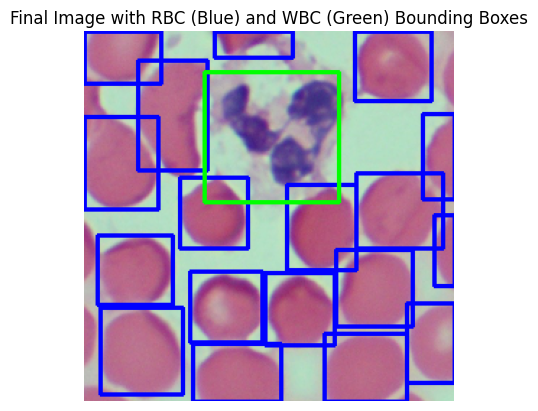

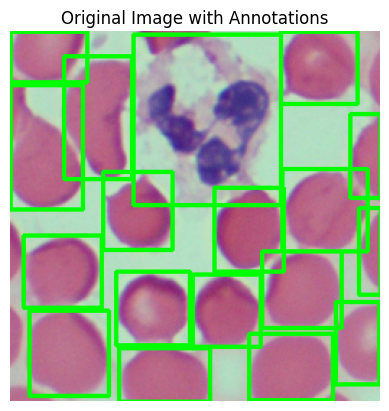

In [31]:
image_name = 'image-1.png'
image_path = 'dataset/BDS/images/' + image_name
img = cv2.imread(image_path)
img_ = img.copy()
rbc_image, wbc_image = mask_cells(img_)
#Take bounding boxes from above functions
rbc_boxes = process_rbc(rbc_image)
wbc_boxes = process_wbc_bounding_box(wbc_image)
#Draw bounding boxes on original image with different colors for rbc and wbc
img_with_boxes = img.copy()
for box in rbc_boxes:
    x_min, y_min, x_max, y_max = box
    cv2.rectangle(img_with_boxes, (y_min, x_min), (y_max, x_max), (255, 0, 0), 2)
for box in wbc_boxes:
    x_min, y_min, x_max, y_max = box
    cv2.rectangle(img_with_boxes, (y_min, x_min), (y_max, x_max), (0, 255, 0), 2)
#Display final image with bounding boxes
plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.title('Final Image with RBC (Blue) and WBC (Green) Bounding Boxes')
plt.axis('off')
plt.show()

#Compare to label from annotations.csv
import pandas as pd
annotations = pd.read_csv('dataset/BDS/annotations.csv')
#Get the annotation for image-1.png
image_annotations = annotations[annotations['image'] == image_name]
#Draw the annotation bounding boxes on the original image
img_with_annotations = img.copy()
for index, row in image_annotations.iterrows():
    x_min = int(row['xmin'])
    y_min = int(row['ymin'])
    x_max = int(row['xmax'])
    y_max = int(row['ymax'])
    label = row['label']
    if label == 'RBC':
        color = (255, 0, 0) # Blue for RBC
    else:
        color = (0, 255, 0) # Green for WBC
    cv2.rectangle(img_with_annotations, (x_min, y_min), (x_max, y_max), color, 2)
#Display image with annotations
plt.imshow(cv2.cvtColor(img_with_annotations, cv2.COLOR_BGR2RGB))
plt.title('Original Image with Annotations')
plt.axis('off')
plt.show()

In [32]:
#Now, we will use some metrics to evaluate the performance of our bounding box detection
#iou
def compute_iou(box1, box2):
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    # Calculate intersection
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    if inter_x_max < inter_x_min or inter_y_max < inter_y_min:
        return 0.0  # No overlap
    
    inter_area = (inter_x_max - inter_x_min) * (inter_y_max - inter_y_min)
    
    # Calculate union
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area
#Calculate IoU for each detected box with each annotation box and find the best match
ious = []
for detected_box in rbc_boxes + wbc_boxes:
    best_iou = 0
    for index, row in image_annotations.iterrows():
        annotation_box = (row['ymin'], row['xmin'], row['ymax'], row['xmax'])
        #print(annotation_box)
        iou = compute_iou(detected_box, annotation_box)
        best_iou = max(best_iou, iou)
        #print(best_iou)
    ious.append(best_iou)
#Calculate average IoU
average_iou = sum(ious) / len(ious) if ious else 0
print(f'Average IoU: {average_iou:.2f}')

Average IoU: 0.83


In [33]:
#Calculate Precision, Recall, F1-score based on IoU threshold (e.g., 0.5)
iou_threshold = 0.5
true_positives = 0
false_positives = 0
false_negatives = 0
for detected_box in rbc_boxes + wbc_boxes:
    match_found = False
    for index, row in image_annotations.iterrows():
        annotation_box = (row['ymin'], row['xmin'], row['ymax'], row['xmax'])
        iou = compute_iou(detected_box, annotation_box)
        if iou >= iou_threshold:
            true_positives += 1
            match_found = True
            break
    if not match_found:
        false_positives += 1
for index, row in image_annotations.iterrows():
    annotation_box = (row['ymin'], row['xmin'], row['ymax'], row['xmax'])
    match_found = False
    for detected_box in rbc_boxes + wbc_boxes:
        iou = compute_iou(detected_box, annotation_box)
        if iou >= iou_threshold:
            match_found = True
            break
    if not match_found:
        false_negatives += 1
precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-score: {f1_score:.2f}')

Precision: 0.95
Recall: 1.00
F1-score: 0.97


In [37]:
#AP and mAP metrics
def calculate_average_precision(detected_boxes, annotation_boxes, iou_threshold=0.5):
    # Sort detected boxes by confidence score (if available)
    # For simplicity, we assume all detected boxes have the same confidence score
    detected_boxes = sorted(detected_boxes, key=lambda x: 1, reverse=True)  # Placeholder for confidence sorting

    true_positives = []
    false_positives = []
    matched_annotations = set()

    for detected_box in detected_boxes:
        best_iou = 0
        best_annotation_index = -1
        for index, annotation_box in enumerate(annotation_boxes):
            iou = compute_iou(detected_box, annotation_box)
            if iou > best_iou:
                best_iou = iou
                best_annotation_index = index
        
        if best_iou >= iou_threshold and best_annotation_index not in matched_annotations:
            true_positives.append(1)
            false_positives.append(0)
            matched_annotations.add(best_annotation_index)
        else:
            true_positives.append(0)
            false_positives.append(1)

    cumulative_true_positives = np.cumsum(true_positives)
    cumulative_false_positives = np.cumsum(false_positives)

    precision = cumulative_true_positives / (cumulative_true_positives + cumulative_false_positives + 1e-6)
    recall = cumulative_true_positives / (len(annotation_boxes) + 1e-6)

    # Calculate Average Precision (AP) using the precision-recall curve
    ap = 0
    for t in np.linspace(0, 1, 11):  # 11-point interpolation
        p = max(precision[recall >= t]) if np.any(recall >= t) else 0
        ap += p / 11

    return ap
# Prepare annotation boxes
annotation_boxes_rbc = []
annotation_boxes_wbc = []
for index, row in image_annotations.iterrows():
    annotation_box = (row['ymin'], row['xmin'], row['ymax'], row['xmax'])
    if row['label'] == 'rbc':
        annotation_boxes_rbc.append(annotation_box)
    else:
        annotation_boxes_wbc.append(annotation_box)
# Calculate AP for RBC and WBC separately
rbc_detected_boxes = rbc_boxes
wbc_detected_boxes = wbc_boxes
rbc_ap = calculate_average_precision(rbc_detected_boxes, annotation_boxes_rbc, iou_threshold=0.5)
wbc_ap = calculate_average_precision(wbc_detected_boxes, annotation_boxes_wbc, iou_threshold=0.5)
print(f'Average Precision for RBC: {rbc_ap:.2f}')
print(f'Average Precision for WBC: {wbc_ap:.2f}')

Average Precision for RBC: 0.90
Average Precision for WBC: 0.91


In [38]:
#Evaluate to all dataset
import os
def evaluate_on_dataset(dataset_path):
    annotations = pd.read_csv(os.path.join(dataset_path, 'annotations.csv'))
    image_files = os.listdir(os.path.join(dataset_path, 'images'))
    
    all_ious = []
    all_precisions = []
    all_recalls = []
    all_f1_scores = []
    all_rbc_aps = []
    all_wbc_aps = []

    for image_file in image_files:
        image_path = os.path.join(dataset_path, 'images', image_file)
        img = cv2.imread(image_path)
        img_ = img.copy()
        rbc_image, wbc_image = mask_cells(img_)
        rbc_boxes = process_rbc(rbc_image)
        wbc_boxes = process_wbc_bounding_box(wbc_image)

        image_annotations = annotations[annotations['image'] == image_file]

        ious = []
        for detected_box in rbc_boxes + wbc_boxes:
            best_iou = 0
            for index, row in image_annotations.iterrows():
                annotation_box = (row['ymin'], row['xmin'], row['ymax'], row['xmax'])
                iou = compute_iou(detected_box, annotation_box)
                best_iou = max(best_iou, iou)
            ious.append(best_iou)
        average_iou = sum(ious) / len(ious) if ious else 0
        all_ious.append(average_iou)

        true_positives = 0
        false_positives = 0
        false_negatives = 0
        for detected_box in rbc_boxes + wbc_boxes:
            match_found = False
            for index, row in image_annotations.iterrows():
                annotation_box = (row['ymin'], row['xmin'], row['ymax'], row['xmax'])
                iou = compute_iou(detected_box, annotation_box)
                if iou >= 0.5:
                    true_positives += 1
                    match_found = True
                    break
            if not match_found:
                false_positives += 1
        for index, row in image_annotations.iterrows():
            annotation_box = (row['ymin'], row['xmin'], row['ymax'], row['xmax'])
            match_found = False
            for detected_box in rbc_boxes + wbc_boxes:
                iou = compute_iou(detected_box, annotation_box)
                if iou >= 0.5:
                    match_found = True
                    break
            if not match_found:
                false_negatives += 1
        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        all_precisions.append(precision)
        all_recalls.append(recall)
        all_f1_scores.append(f1_score)
        annotation_boxes_rbc = []
        annotation_boxes_wbc = []
        for index, row in image_annotations.iterrows():
            annotation_box = (row['ymin'], row['xmin'], row['ymax'], row['xmax'])
            if row['label'] == 'rbc':
                annotation_boxes_rbc.append(annotation_box)
            else:
                annotation_boxes_wbc.append(annotation_box)
        rbc_ap = calculate_average_precision(rbc_boxes, annotation_boxes_rbc, iou_threshold=0.5)
        wbc_ap = calculate_average_precision(wbc_boxes, annotation_boxes_wbc, iou_threshold=0.5)
        all_rbc_aps.append(rbc_ap)
        all_wbc_aps.append(wbc_ap)
    print(f'Average IoU across dataset: {np.mean(all_ious):.2f}')
    print(f'Average Precision across dataset: {np.mean(all_precisions):.2f}')
    print(f'Average Recall across dataset: {np.mean(all_recalls):.2f}')
    print(f'Average F1-score across dataset: {np.mean(all_f1_scores):.2f}')
    print(f'Average AP for RBC across dataset: {np.mean(all_rbc_aps):.2f}')
    print(f'Average AP for WBC across dataset: {np.mean(all_wbc_aps):.2f}')
evaluate_on_dataset('dataset/BDS')


Average IoU across dataset: 0.73
Average Precision across dataset: 0.86
Average Recall across dataset: 0.73
Average F1-score across dataset: 0.78
Average AP for RBC across dataset: 0.67
Average AP for WBC across dataset: 0.75
